In [12]:
!pip install --quiet -r requirements.txt

In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import textstat
import math

In [ ]:
ROOT_DIR = os.path.join(os.getcwd(), '..', '..')
DATA_PREPR = Path(ROOT_DIR) / "datos/pre-processed"
DATA_RAW = Path(ROOT_DIR) / "datos/raw"

In [5]:
def convertir_txt_data_frame(ruta_path):
    txt_files = list(ruta_path.glob("*.txt"))
    data = []
    for path in txt_files:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            data.append({"text": content})

    df = pd.DataFrame(data)
    return df

In [6]:
temp_cochrane_train_non_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/train/non_pls')
temp_cochrane_train_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/train/pls')
temp_cochrane_test_non_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/test/non_pls')
temp_cochrane_test_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/test/pls')
print(f'Archivos leidos cochrane train non-pls {len(temp_cochrane_train_non_pls)}')
print(f'Archivos leidos cochrane train pls {len(temp_cochrane_train_pls)}')
print(f'Archivos leidos cochrane test non-pls {len(temp_cochrane_test_non_pls)}')
print(f'Archivos leidos cochrane test pls {len(temp_cochrane_test_pls)}')
temp_cochrane_train_non_pls['pls'] = 0
temp_cochrane_train_pls['pls'] = 1
temp_cochrane_test_non_pls['pls'] = 0
temp_cochrane_test_pls['pls'] = 1

Archivos leidos cochrane train non-pls 31118
Archivos leidos cochrane train pls 16241
Archivos leidos cochrane test non-pls 7664
Archivos leidos cochrane test pls 3940


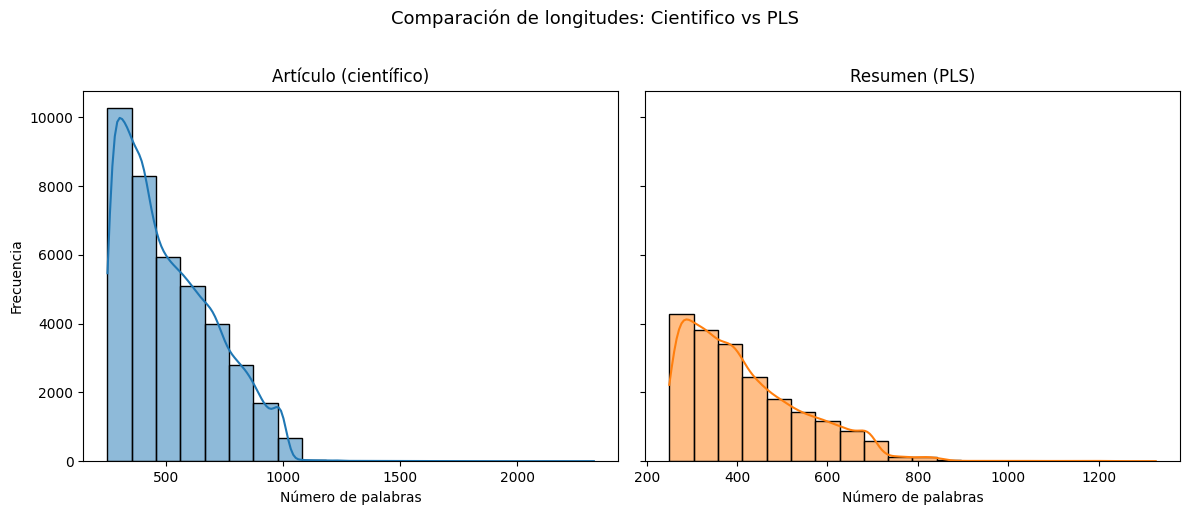

In [7]:
df_temp_cientific = pd.concat([temp_cochrane_train_non_pls['text'],temp_cochrane_test_non_pls['text']],ignore_index=True)
df_temp_pls = pd.concat([temp_cochrane_train_pls['text'],temp_cochrane_test_pls['text']],ignore_index=True)

len_article_words = df_temp_cientific.astype(str).apply(lambda x: len(x.split()))
len_summary_words = df_temp_pls.astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(len_article_words, bins=20, color="tab:blue", ax=axes[0], kde=True)
axes[0].set_title("Artículo (científico)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")

sns.histplot(len_summary_words, bins=20, color="tab:orange", ax=axes[1], kde=True)
axes[1].set_title("Resumen (PLS)")
axes[1].set_xlabel("Número de palabras")

plt.suptitle("Comparación de longitudes: Cientifico vs PLS", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
df_csv = pd.concat([temp_cochrane_train_non_pls,temp_cochrane_train_pls,temp_cochrane_test_non_pls,temp_cochrane_test_pls],ignore_index=True)
rows_per_chunk = 15000
for i, start in enumerate(range(0, len(df_csv), rows_per_chunk), start=1):
    ##Se guarda el dato en bloques para que el archivo resultante sea inferior a 100MB y pueda subirse sin problemas a Github
    df_csv.iloc[start:start+rows_per_chunk].to_csv(f"{DATA_PREPR}/data_chunk_{i}.csv", index=False)

In [8]:
def convertir_txt_data_frame_test(ruta_path,tipo):
    txt_files = list(ruta_path.glob("*.txt"))
    data = []
    for path in txt_files:

        if 'accumulated' in path.stem.lower():
            continue

        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            name_clean = path.stem
            name_clean = name_clean.replace('-abstract', '').replace('-pls', '')
            name_clean = name_clean.strip()
            content = f.read().strip()
            data.append({"name":name_clean,tipo: content})

    df = pd.DataFrame(data)
    return df


temp_cochrane_train_non_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/train/non_pls','article')
temp_cochrane_train_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/train/pls','summary')
temp_cochrane_test_non_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/test/non_pls','article')
temp_cochrane_test_pls = convertir_txt_data_frame_test(DATA_RAW/'cochrane/test/pls','summary')

def combinar_datasets_por_name(*dfs):
    df_final = dfs[0]
    for df in dfs[1:]:
        df_final = pd.merge(df_final, df, on='name', how='inner')
    return df_final

cochrane_train = combinar_datasets_por_name(temp_cochrane_train_non_pls, temp_cochrane_train_pls)
cochrane_test = combinar_datasets_por_name(temp_cochrane_test_non_pls, temp_cochrane_test_pls)
cochrane_total = pd.concat([cochrane_train, cochrane_test], ignore_index=True)

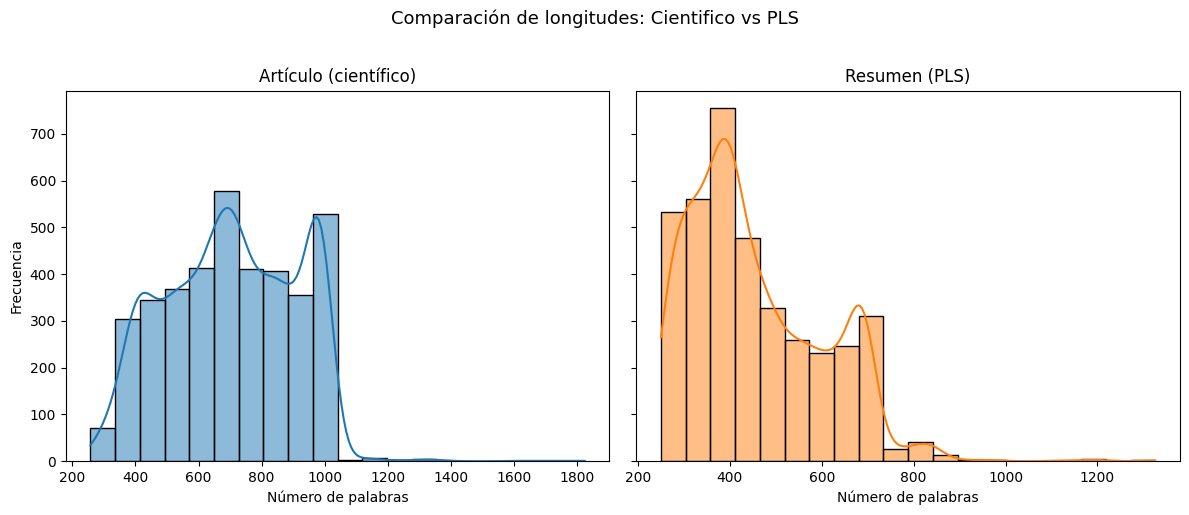

In [9]:
len_article_words = cochrane_total['article'].astype(str).apply(lambda x: len(x.split()))
len_summary_words = cochrane_total['summary'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(len_article_words, bins=20, color="tab:blue", ax=axes[0], kde=True)
axes[0].set_title("Artículo (científico)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")

sns.histplot(len_summary_words, bins=20, color="tab:orange", ax=axes[1], kde=True)
axes[1].set_title("Resumen (PLS)")
axes[1].set_xlabel("Número de palabras")

plt.suptitle("Comparación de longitudes: Cientifico vs PLS", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

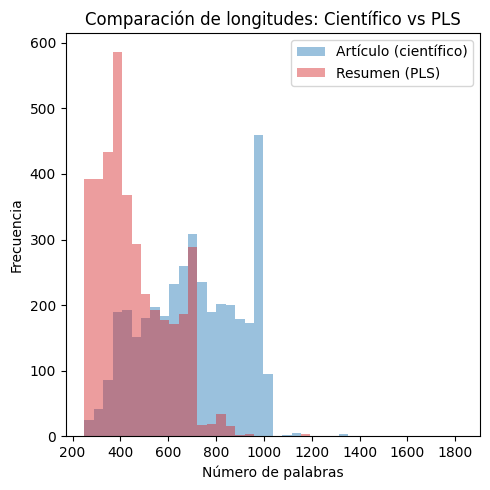

In [40]:
import numpy as np

bins = np.histogram_bin_edges(
    np.concatenate([len_article_words.to_numpy(), len_summary_words.to_numpy()]),
    bins=40
)

plt.figure(figsize=(5, 5))
sns.histplot(len_article_words, bins=bins, stat="count",
             alpha=0.45, color="tab:blue", edgecolor='none', label="Artículo (científico)")
sns.histplot(len_summary_words, bins=bins, stat="count",
             alpha=0.45, color="tab:red", edgecolor='none', label="Resumen (PLS)")

plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.title("Comparación de longitudes: Científico vs PLS")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# pip install textstat
import numpy as np
import pandas as pd
import textstat

def text_standard_metrics(text: str) -> pd.Series:
    text = "" if text is None else str(text)
    S = max(1, textstat.sentence_count(text))             # oraciones
    W = textstat.lexicon_count(text, removepunct=True)    # palabras (sin puntuación)
    P = textstat.polysyllabcount(text)                    # palabras con ≥3 sílabas

    # Grado estándar (promedio/agregado de varias fórmulas)
    try:
        ts_grade = float(textstat.text_standard(text, float_output=True))
    except Exception:
        ts_grade = np.nan

    return pd.Series({
        "text_standard": ts_grade,                         # grado agregado (float)
        "sentences": S,
        "words": W,
        "polysyllables": P,
        "pct_polysyllables": (100.0 * P / W) if W else 0.0
    })

def grade_category(score: float) -> str:
    if pd.isna(score): return "NA"
    if score < 6:   return "Muy fácil (<6)"
    if score < 9:   return "Fácil (6–8)"
    if score < 11:  return "Medio (9–10)"
    if score < 13:  return "Difícil (11–12)"
    if score < 16:  return "Muy difícil (13–15)"
    return "Profesional (≥16)"

# ---- aplica a tus columnas ----
art_stats = cochrane_total['article'].astype(str).apply(text_standard_metrics)
pls_stats = cochrane_total['summary'].astype(str).apply(text_standard_metrics)
art_stats["dataset"] = "Article"
pls_stats["dataset"] = "PLS"

all_stats = pd.concat([art_stats, pls_stats], ignore_index=True)
all_stats["ts_cat"] = all_stats["text_standard"].apply(grade_category)

summary = (all_stats
           .groupby("dataset")[["text_standard", "pct_polysyllables", "sentences", "words"]]
           .agg(["mean", "median", "std"])
           .round(2))

cat_pct = (all_stats
           .groupby(["dataset","ts_cat"]).size()
           .unstack(fill_value=0)
           .pipe(lambda df: (df.div(df.sum(axis=1), axis=0) * 100).round(1)))


In [43]:
summary

text_standard              pct_polysyllables              sentences  \
                 mean median   std              mean median   std      mean   
dataset                                                                       
Article         13.89   14.0  1.98             24.74  24.62  3.23     47.16   
PLS             14.23   14.0  2.18             20.57  20.50  4.37     22.03   

                        words                 
        median    std    mean median     std  
dataset                                       
Article   45.0  20.44  700.60  700.0  202.18  
PLS       20.0   8.07  455.27  415.5  145.21

In [44]:
cat_pct

ts_cat,Difícil (11–12),Fácil (6–8),Medio (9–10),Muy difícil (13–15),Profesional (≥16)
dataset,,,,,
Article,17.6,0.5,2.3,59.6,20.1
PLS,21.2,0.1,2.7,48.4,27.5


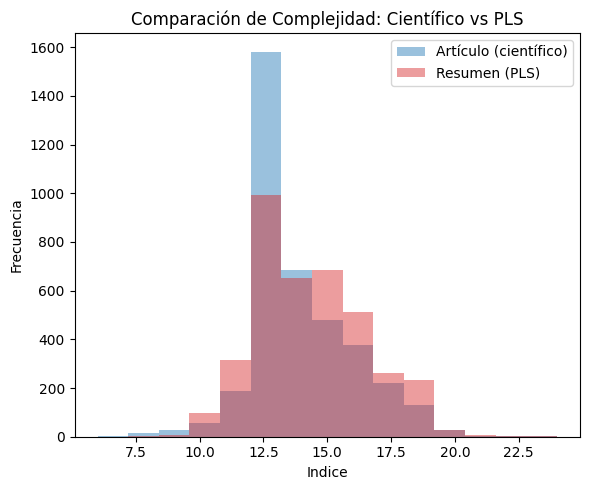

In [55]:
bins = np.histogram_bin_edges(
    np.concatenate([art_stats["text_standard"].dropna().to_numpy(), pls_stats["text_standard"].dropna().to_numpy()]),
    bins=15
)

plt.figure(figsize=(6, 5))
sns.histplot(art_stats["text_standard"].dropna(), bins=bins, stat="count",
             alpha=0.45, color="tab:blue",edgecolor='none', label="Artículo (científico)")
sns.histplot(pls_stats["text_standard"].dropna(), bins=bins, stat="count",
             alpha=0.45, color="tab:red",edgecolor='none', label="Resumen (PLS)")

plt.xlabel("Indice")
plt.ylabel("Frecuencia")
plt.title("Comparación de Complejidad: Científico vs PLS")
plt.legend()
plt.tight_layout()
plt.show()


In [84]:
def fre_score(text: str) -> float:
    text = "" if text is None else str(text)
    try:
        return float(textstat.flesch_reading_ease(text))
    except Exception:
        return np.nan
    
def fre_grade_category(score: float) -> str:
    if pd.isna(score): return "NA"
    if score < 10:   return "Extremadamente Dificil < 10"
    if score < 30:  return "Muy Dificil 10 - 30"
    if score < 50:  return "Dificil 30  - 50"
    if score < 60:  return "Ligeramente Dificil 50 - 60"
    return "Estandar (Publico General) > 60"

art_stats = cochrane_total['article'].astype(str).apply(fre_score).to_frame(name='fre')
pls_stats = cochrane_total['summary'].astype(str).apply(fre_score).to_frame(name='fre')

art_stats['dataset'] = 'Article'
pls_stats['dataset'] = 'PLS'

all_stats = pd.concat([art_stats, pls_stats], ignore_index=True)

all_stats["ts_cat"] = all_stats['fre'].apply(fre_grade_category)

summary = (all_stats.groupby('dataset')['fre']
           .agg(['mean', 'median', 'std', 'min', 'max'])
           .round(2))

cat_pct = (all_stats
           .groupby(["dataset","ts_cat"]).size()
           .unstack(fill_value=0)
           .pipe(lambda df: (df.div(df.sum(axis=1), axis=0) * 100).round(1)))


In [85]:
summary

,mean,median,std,min,max
dataset,,,,,
Article,32.98,33.44,9.92,-14.09,70.97
PLS,35.97,35.89,10.47,-0.27,70.84


In [86]:
cat_pct

ts_cat,Dificil 30 - 50,Estandar (Publico General) > 60,Extremadamente Dificil < 10,Ligeramente Dificil 50 - 60,Muy Dificil 10 - 30
dataset,,,,,
Article,60.5,0.2,1.6,3.3,34.5
PLS,63.6,1.0,0.9,7.7,26.8


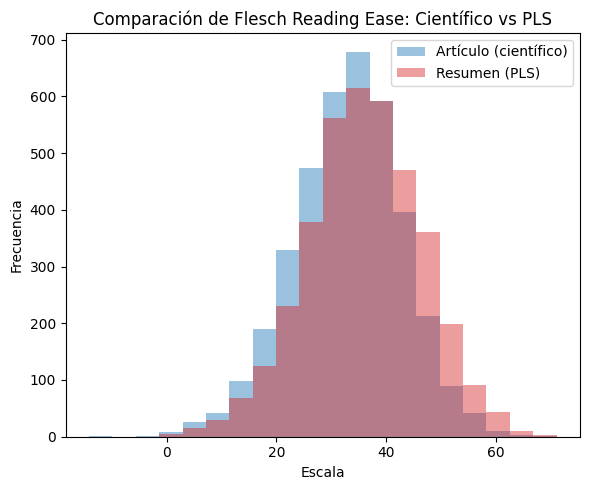

In [83]:
bins = np.histogram_bin_edges(
    np.concatenate([art_stats["fre"].dropna().to_numpy(), pls_stats["fre"].dropna().to_numpy()]),
    bins=20
)

plt.figure(figsize=(6, 5))
sns.histplot(art_stats["fre"].dropna(), bins=bins, stat="count",
             alpha=0.45, color="tab:blue",edgecolor='none', label="Artículo (científico)")
sns.histplot(pls_stats["fre"].dropna(), bins=bins, stat="count",
             alpha=0.45, color="tab:red",edgecolor='none', label="Resumen (PLS)")

plt.xlabel("Escala")
plt.ylabel("Frecuencia")
plt.title("Comparación de Flesch Reading Ease: Científico vs PLS")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
mask = cochrane_total['article'].fillna('').astype(str).apply(lambda x: len(x.split())) <= 2000

df_limit = cochrane_total.loc[mask].reset_index(drop=True)

df_train, df_temp = train_test_split(df_limit, test_size=0.2, random_state=42, shuffle=True)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, shuffle=True)

df_train.to_csv(f"{DATA_PREPR}/data_finetuning_train.csv", index=False)
df_val.to_csv(f"{DATA_PREPR}/data_finetuning_val.csv", index=False)
df_test.to_csv(f"{DATA_PREPR}/data_finetuning_test.csv", index=False)

print(f'Registros totales generados para entrenamiento: {len(df_train)}')
print(f'Registros totales generados para validacion: {len(df_val)}')
print(f'Registros totales generados para test: {len(df_test)}')

Registros totales generados para entrenamiento: 3038
Registros totales generados para validacion: 380
Registros totales generados para test: 380
